# Methods Notebook: Extracting Call Samples for KMeans Clustering

## Imports Section:

In [1]:
import numpy as np
import pandas as pd
import random
import scipy
from scipy import stats
import datetime as dt
import dask.dataframe as dd

In [2]:
import librosa
import warnings

In [3]:
import glob
import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from pathlib import Path

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

In [5]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
import src.file_dealer as file_dealer

## Function Definitions (most important functions are in `src/`)
### Below are the functions used for plotting and visualization

In [6]:
FREQ_COLORS = {'LF':'cyan', 'HF':'orange'}

In [ ]:
file_sites = {'20220730_053000':'Carp',
 '20220826_070000':'Central',
 '20220727_083000':'Foliage',
 '20220829_090000':'Foliage'}
bd2_dets_save_dir = Path(f'20250101__group_threshold_sweep_results')
raventxt_human_files_dir = f'{Path.home()}/Documents/mila-human-wav-txt'
extension = ".txt"
sep = "\t"

SITE_NAMES = {'Carp':'Carp Pond', 'Foliage':'Foliage', 'Central':'Central Pond'}

file_keys = list(file_sites.keys())
file_keys

['20220730_053000', '20220826_070000', '20220727_083000', '20220829_090000']

In [8]:
batdetect2_eval = pd.read_csv(bd2_dets_save_dir / '20250101__bd2_eval_results_per_thresh_and_file.csv', index_col=0)
batdetect2_eval_LF = pd.read_csv(bd2_dets_save_dir / '20250101__bd2_LFeval_results_per_thresh_and_file.csv', index_col=0)
batdetect2_eval_HF = pd.read_csv(bd2_dets_save_dir / '20250101__bd2_HFeval_results_per_thresh_and_file.csv', index_col=0)

In [ ]:
batdetect2_eval

,SNR_threshold,detection_threshold,num_bd2_detections,num_human_annotations,true_positives,false_positives,false_negatives,true_negatives,precision,recall,input_file_name,site_name
0,0.0,0.05,1935,863,819,1116,44,0,0.423256,0.949015,20220730_053000.WAV,Carp Pond
1,0.0,0.06,1434,863,808,626,55,0,0.563459,0.936269,20220730_053000.WAV,Carp Pond
2,0.0,0.07,1187,863,806,381,57,0,0.679023,0.933951,20220730_053000.WAV,Carp Pond
3,0.0,0.08,1045,863,800,245,63,0,0.765550,0.926999,20220730_053000.WAV,Carp Pond
4,0.0,0.09,967,863,796,171,67,0,0.823164,0.922364,20220730_053000.WAV,Carp Pond
...,...,...,...,...,...,...,...,...,...,...,...,...
667,22.0,0.56,0,3,0,0,3,0,NaN,0.000000,20220829_090000.WAV,Foliage
668,22.0,0.57,0,3,0,0,3,0,NaN,0.000000,20220829_090000.WAV,Foliage
669,22.0,0.58,0,3,0,0,3,0,NaN,0.000000,20220829_090000.WAV,Foliage
670,22.0,0.59,0,3,0,0,3,0,NaN,0.000000,20220829_090000.WAV,Foliage


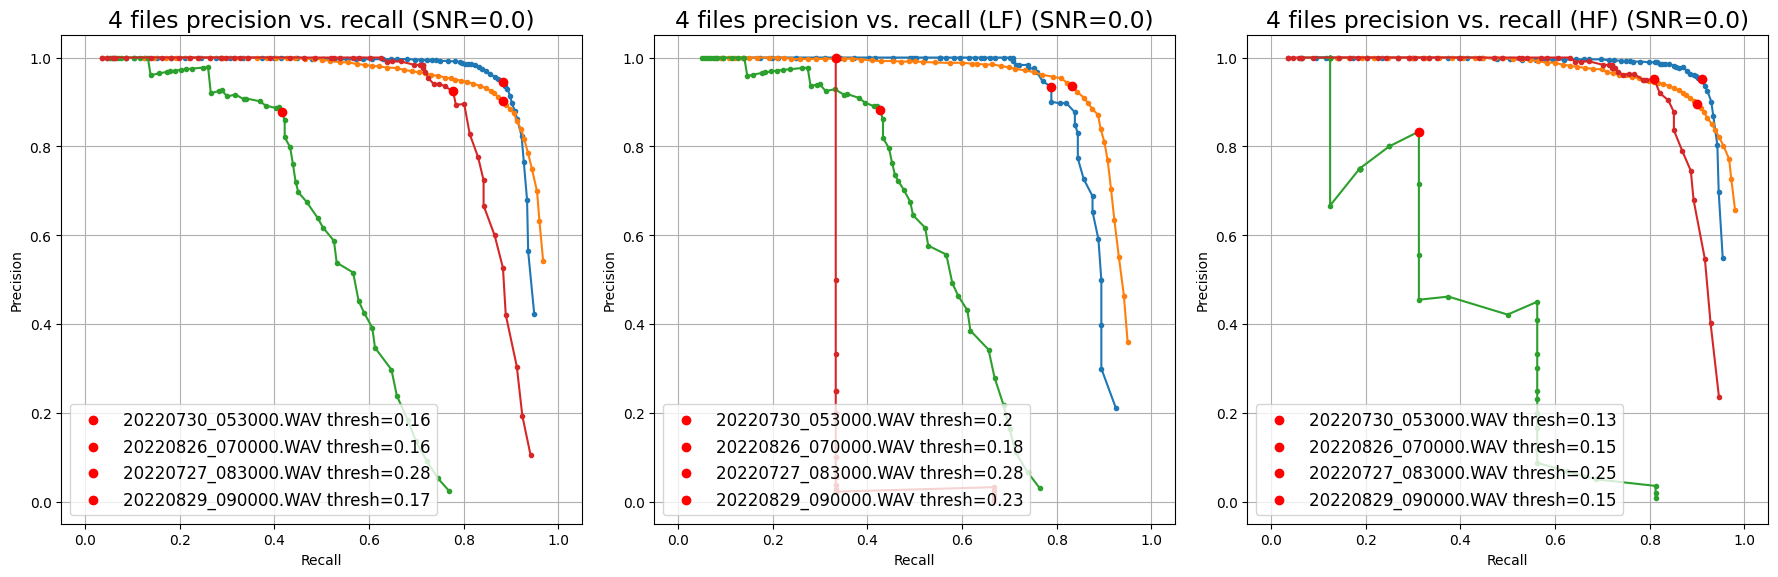

In [10]:
fig, (ax1, ax2, ax3), = plt.subplots(1, 3, figsize=(18,6))
plt.rcParams.update({'font.size':14})
ax1.set_title(f'4 files precision vs. recall (SNR={0.0})')
for file in batdetect2_eval['input_file_name'].unique():
    batdetect2_eval_file = batdetect2_eval[batdetect2_eval['input_file_name']==file].copy()
    batdetect2_eval_file_SNR = batdetect2_eval_file[batdetect2_eval_file['SNR_threshold']==0.0].copy()
    thresholds = batdetect2_eval_file_SNR['detection_threshold']
    file_precisions_SNR = batdetect2_eval_file_SNR['precision']
    file_recalls_SNR = batdetect2_eval_file_SNR['recall']
    common_max = (file_precisions_SNR * file_recalls_SNR).argmax()
    ax1.plot(file_recalls_SNR, file_precisions_SNR, marker='.')
    ax1.scatter(file_recalls_SNR.iloc[common_max], file_precisions_SNR.iloc[common_max], color='r',
                label=f'{Path(file).name} thresh={round(thresholds[common_max], 3)}', zorder=2)
ax1.grid(which='both')
ax1.set_xlim(-0.05,1.05)
ax1.set_ylim(-0.05,1.05)
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.legend(loc='lower left', fontsize=12)

ax2.set_title(f'4 files precision vs. recall (LF) (SNR={0.0})')
for file in batdetect2_eval_LF['input_file_name'].unique():
    batdetect2_eval_file = batdetect2_eval_LF[batdetect2_eval_LF['input_file_name']==file].copy()
    batdetect2_eval_file_SNR = batdetect2_eval_file[batdetect2_eval_file['SNR_threshold']==0.0].copy()
    thresholds = batdetect2_eval_file_SNR['detection_threshold']
    file_precisions_SNR = batdetect2_eval_file_SNR['precision']
    file_recalls_SNR = batdetect2_eval_file_SNR['recall']
    common_max = (file_precisions_SNR * file_recalls_SNR).argmax()
    ax2.plot(file_recalls_SNR, file_precisions_SNR, marker='.')
    ax2.scatter(file_recalls_SNR.iloc[common_max], file_precisions_SNR.iloc[common_max], color='r',
                label=f'{Path(file).name} thresh={round(thresholds[common_max], 3)}', zorder=2)
ax2.grid(which='both')
ax2.set_xlim(-0.05,1.05)
ax2.set_ylim(-0.05,1.05)
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc='lower left', fontsize=12)

ax3.set_title(f'4 files precision vs. recall (HF) (SNR={0.0})')
for file in batdetect2_eval_HF['input_file_name'].unique():
    batdetect2_eval_file = batdetect2_eval_HF[batdetect2_eval_HF['input_file_name']==file].copy()
    batdetect2_eval_file_SNR = batdetect2_eval_file[batdetect2_eval_file['SNR_threshold']==0.0].copy()
    thresholds = batdetect2_eval_file_SNR['detection_threshold']
    file_precisions_SNR = batdetect2_eval_file_SNR['precision']
    file_recalls_SNR = batdetect2_eval_file_SNR['recall']
    common_max = (file_precisions_SNR * file_recalls_SNR).argmax()
    ax3.plot(file_recalls_SNR, file_precisions_SNR, marker='.')
    ax3.scatter(file_recalls_SNR.iloc[common_max], file_precisions_SNR.iloc[common_max], color='r', 
                label=f'{Path(file).name} thresh={round(thresholds[common_max], 3)}', zorder=2)
ax3.grid(which='both')
ax3.set_xlim(-0.05,1.05)
ax3.set_ylim(-0.05,1.05)
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.legend(loc='lower left', fontsize=12)

fig.tight_layout()
plt.show()

In [11]:
def get_precision_and_recall_from_metrics(true_positives, false_positives, false_negatives):
    denom_precision = (true_positives + false_positives)
    denom_recall = (true_positives + false_negatives)
    precision = true_positives / denom_precision
    recall = true_positives / denom_recall
    
    return precision, recall

In [12]:
all_files_metrics_by_det_thresh = batdetect2_eval[batdetect2_eval['SNR_threshold']==4.0].groupby('detection_threshold')
all_files_metrics_summed_by_det_thresh = all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                            'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
precision, recall = get_precision_and_recall_from_metrics(all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_negatives'])
all_files_metrics_summed_by_det_thresh['precision'] = precision
all_files_metrics_summed_by_det_thresh['recall'] = recall

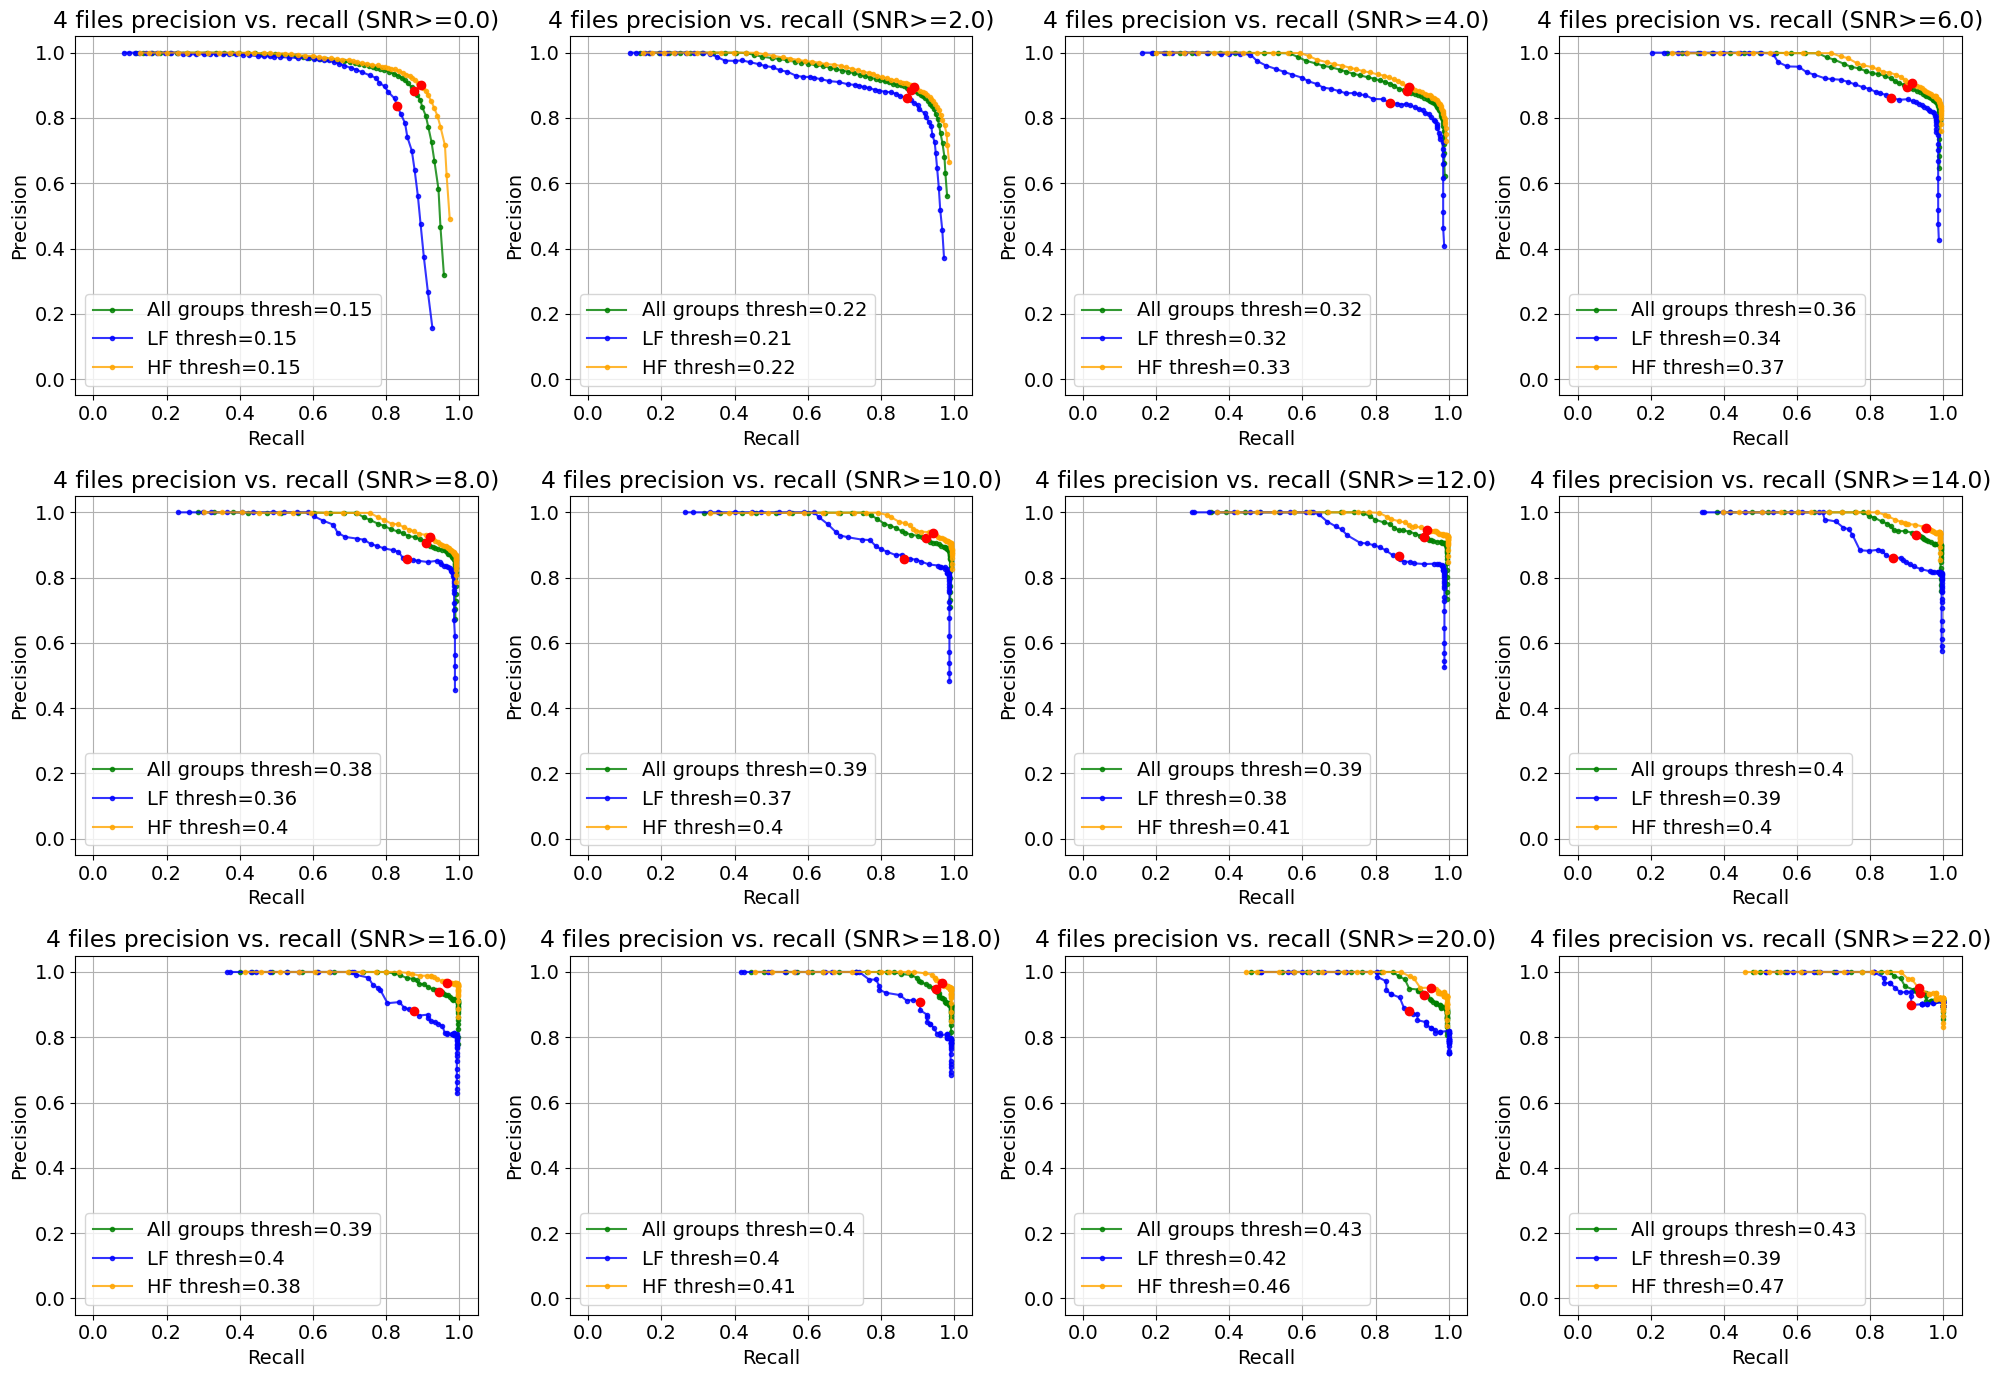

In [13]:
increment = 2.0

snr_thresholds = np.arange(0, 22+increment, increment)
fig, ax_all, = plt.subplots(3, 4, figsize=(20,14))
ax_flatten = ax_all.flatten()

plt.rcParams.update({'font.size':14})
for snr_num, SNR_threshold in enumerate(snr_thresholds):
    ax = ax_flatten[snr_num]
    all_files_metrics_by_det_thresh = batdetect2_eval[batdetect2_eval['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
    all_files_metrics_summed_by_det_thresh = all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                                'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
    precision, recall = get_precision_and_recall_from_metrics(all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_negatives'])

    ax.set_title(f'4 files precision vs. recall (SNR>={SNR_threshold})')
    thresholds = all_files_metrics_summed_by_det_thresh.index
    quality = np.abs(all_files_metrics_summed_by_det_thresh['false_negatives']-all_files_metrics_summed_by_det_thresh['false_positives'])
    quality_ind = quality.argmin()
    ax.plot(recall, precision, marker='.', color='green', alpha=0.8, label=f'All groups thresh={round(thresholds[quality_ind], 3)}')
    ax.scatter(recall.iloc[quality_ind], precision.iloc[quality_ind], color='r', zorder=2)

    all_files_metrics_by_det_thresh = batdetect2_eval_LF[batdetect2_eval_LF['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
    all_files_metrics_summed_by_det_thresh = all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                                'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
    precision, recall = get_precision_and_recall_from_metrics(all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_negatives'])
    thresholds = all_files_metrics_summed_by_det_thresh.index
    LF_quality = np.abs(all_files_metrics_summed_by_det_thresh['false_negatives']-all_files_metrics_summed_by_det_thresh['false_positives'])
    LF_quality_ind = LF_quality.argmin()
    ax.plot(recall, precision, marker='.', color='blue', alpha=0.8, label=f'LF thresh={round(thresholds[LF_quality_ind], 3)}')
    ax.scatter(recall.iloc[LF_quality_ind], precision.iloc[LF_quality_ind], color='r', zorder=2)

    all_files_metrics_by_det_thresh = batdetect2_eval_HF[batdetect2_eval_HF['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
    all_files_metrics_summed_by_det_thresh = all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                                'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
    precision, recall = get_precision_and_recall_from_metrics(all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_negatives'])
    thresholds = all_files_metrics_summed_by_det_thresh.index
    HF_quality = np.abs(all_files_metrics_summed_by_det_thresh['false_negatives']-all_files_metrics_summed_by_det_thresh['false_positives'])
    HF_quality_ind = HF_quality.argmin()
    ax.plot(recall, precision, marker='.', color='orange', alpha=0.8, label=f'HF thresh={round(thresholds[HF_quality_ind], 3)}')
    ax.scatter(recall.iloc[HF_quality_ind], precision.iloc[HF_quality_ind], color='r', zorder=2)
    
    ax.grid(which='both')
    ax.set_xlim(-0.05,1.05)
    ax.set_ylim(-0.05,1.05)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(loc='lower left', fontsize=14)

fig.tight_layout()
plt.show()

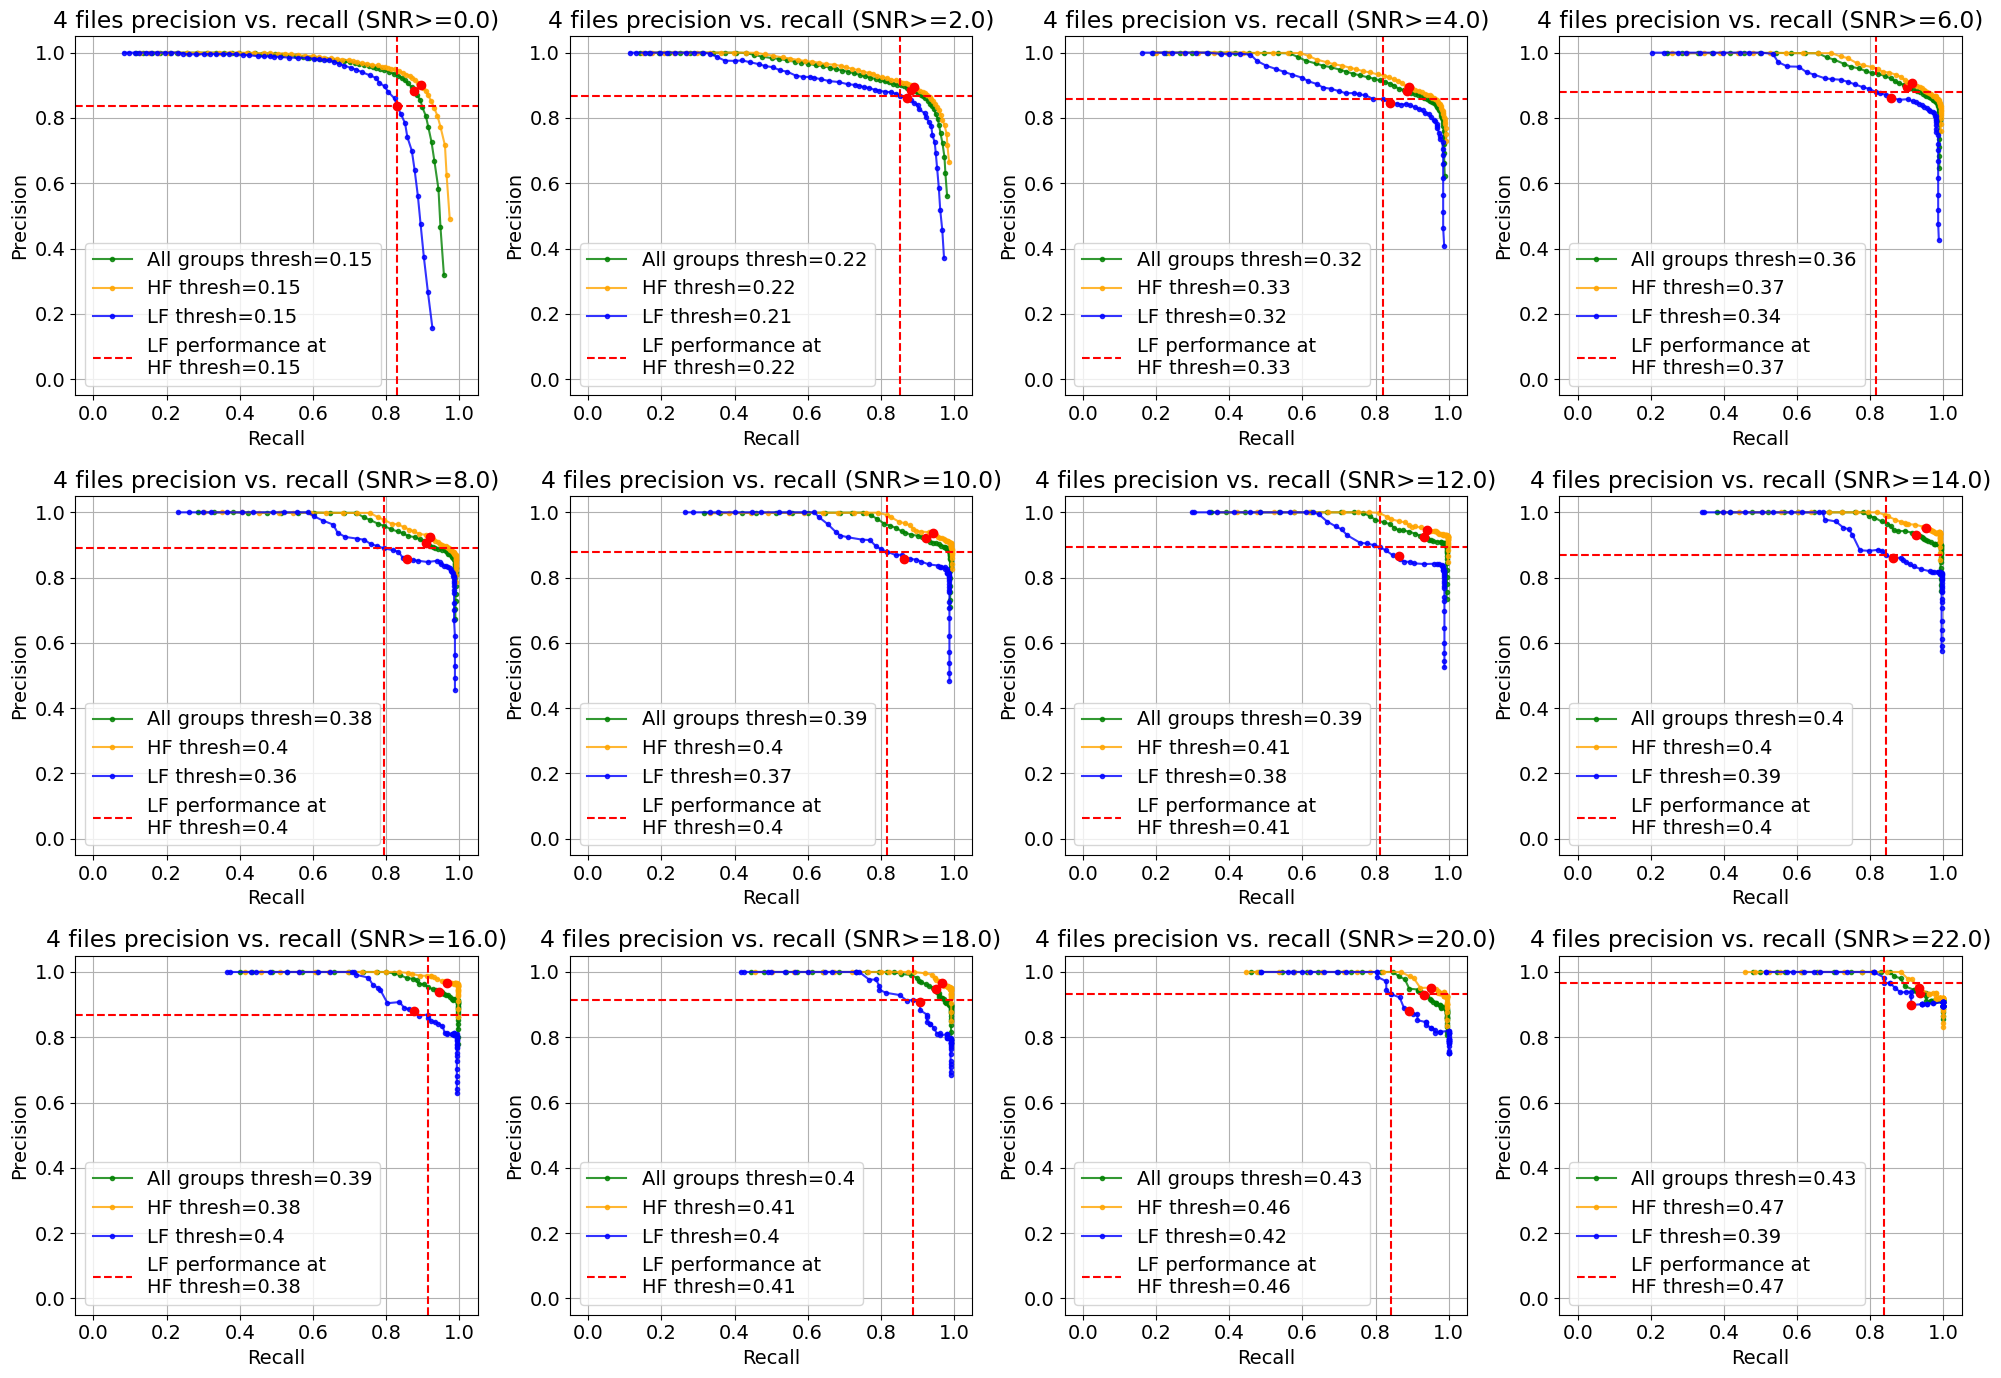

In [14]:
increment = 2.0
snrs_thresholds = np.arange(0, 22+increment, increment)

fig, ax_all, = plt.subplots(3, 4, figsize=(20,14))
ax_flatten = ax_all.flatten()

plt.rcParams.update({'font.size':14})
for snr_num, SNR_threshold in enumerate(snrs_thresholds):
    ax = ax_flatten[snr_num]
    all_files_metrics_by_det_thresh = batdetect2_eval[batdetect2_eval['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
    all_files_metrics_summed_by_det_thresh = all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                                'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
    precision, recall = get_precision_and_recall_from_metrics(all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_negatives'])

    ax.set_title(f'4 files precision vs. recall (SNR>={SNR_threshold})')
    thresholds = all_files_metrics_summed_by_det_thresh.index
    quality = np.abs(all_files_metrics_summed_by_det_thresh['false_negatives']-all_files_metrics_summed_by_det_thresh['false_positives'])
    quality_ind = quality.argmin()
    ax.plot(recall, precision, marker='.', color='green', alpha=0.8, label=f'All groups thresh={round(thresholds[quality_ind], 3)}')
    ax.scatter(recall.iloc[quality_ind], precision.iloc[quality_ind], color='r', zorder=2)

    all_files_metrics_by_det_thresh = batdetect2_eval_HF[batdetect2_eval_HF['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
    all_files_metrics_summed_by_det_thresh = all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                                'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
    precision, recall = get_precision_and_recall_from_metrics(all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_negatives'])
    thresholds = all_files_metrics_summed_by_det_thresh.index
    HF_quality = np.abs(all_files_metrics_summed_by_det_thresh['false_negatives']-all_files_metrics_summed_by_det_thresh['false_positives'])
    HF_quality_ind = HF_quality.argmin()
    ax.plot(recall, precision, marker='.', color='orange', alpha=0.8, label=f'HF thresh={round(thresholds[HF_quality_ind], 3)}')
    ax.scatter(recall.iloc[HF_quality_ind], precision.iloc[HF_quality_ind], color='r', zorder=2)

    all_files_metrics_by_det_thresh = batdetect2_eval_LF[batdetect2_eval_LF['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
    all_files_metrics_summed_by_det_thresh = all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                                'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
    precision, recall = get_precision_and_recall_from_metrics(all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_negatives'])
    thresholds = all_files_metrics_summed_by_det_thresh.index
    LF_quality = np.abs(all_files_metrics_summed_by_det_thresh['false_negatives']-all_files_metrics_summed_by_det_thresh['false_positives'])
    LF_quality_ind = LF_quality.argmin()
    ax.plot(recall, precision, marker='.', color='blue', alpha=0.8, label=f'LF thresh={round(thresholds[LF_quality_ind], 3)}')
    ax.scatter(recall.iloc[LF_quality_ind], precision.iloc[LF_quality_ind], color='r', zorder=2)
    ax.axvline(x=recall.iloc[HF_quality_ind], linestyle='dashed', color='r')
    ax.axhline(y=precision.iloc[HF_quality_ind], linestyle='dashed', color='r', label=f'LF performance at \nHF thresh={round(thresholds[HF_quality_ind], 3)}')
    # ax.axvline(x=recall.iloc[LF_quality_ind], linestyle='dashed', color='b')
    # ax.axhline(y=precision.iloc[LF_quality_ind], linestyle='dashed', color='b')

    ax.grid(which='both')
    ax.set_xlim(-0.05,1.05)
    ax.set_ylim(-0.05,1.05)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(loc='lower left', fontsize=14)

    
fig.tight_layout()
plt.show()

In [16]:
import matplotlib.cm as cm

# Get a colormap and normalize function for the colors
HF_colormap = cm.Reds
LF_colormap = cm.Blues
colormap = cm.Greys
norm = plt.Normalize(vmin=min(snr_thresholds), vmax=max(snr_thresholds))

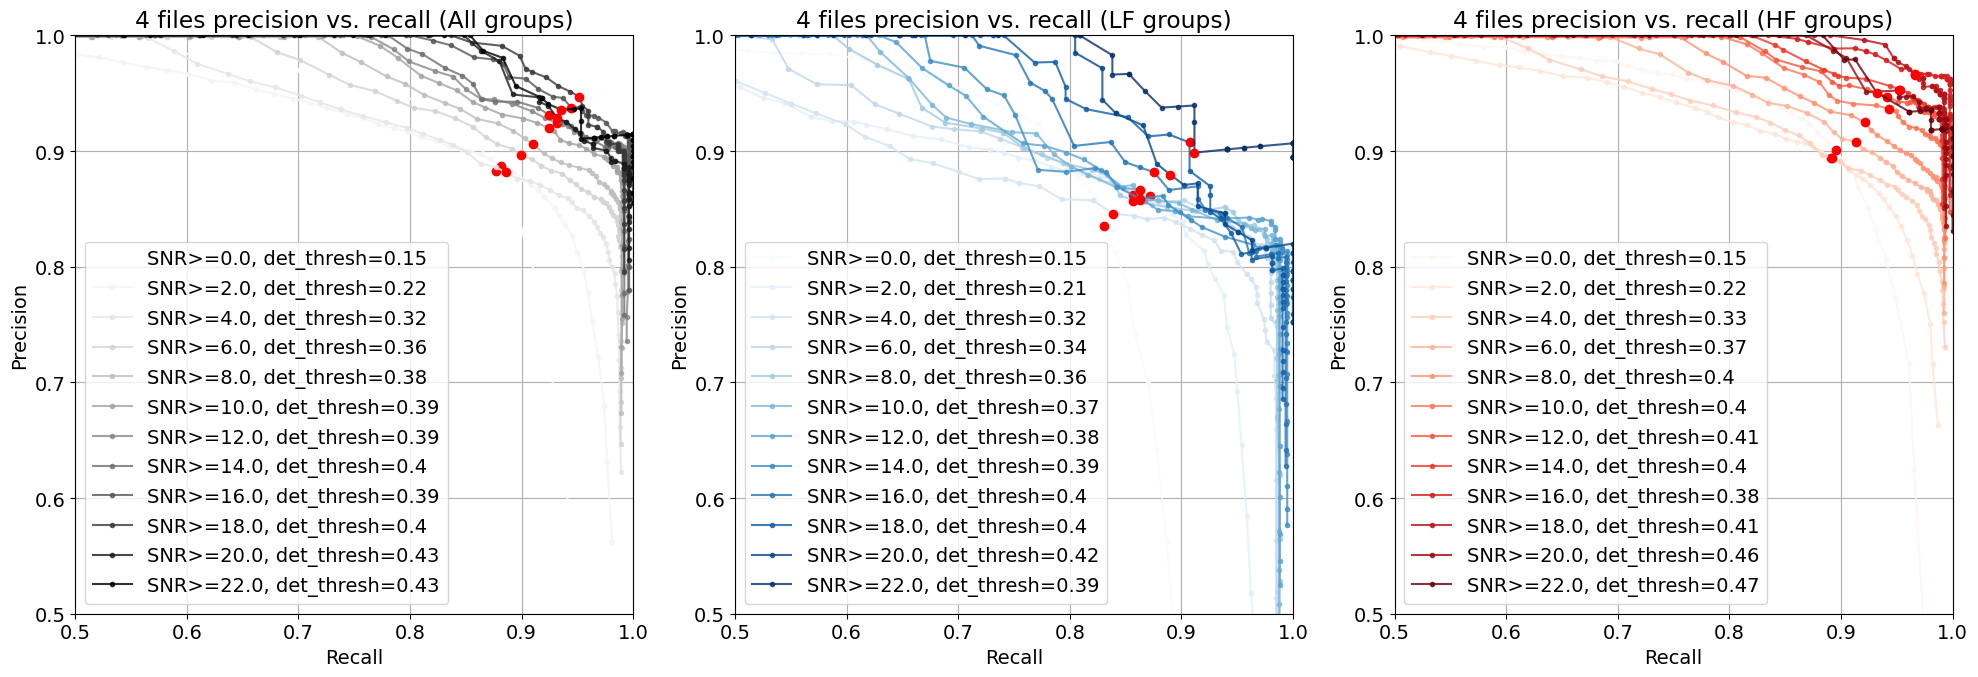

In [17]:
increment = 2.0

snr_thresholds = np.arange(0, 22+increment, increment)
fig, ax_all, = plt.subplots(1, 3, figsize=(20,7))
ax_flatten = ax_all.flatten()

plt.rcParams.update({'font.size':14})
ax = ax_flatten[0]
ax.set_title(f'4 files precision vs. recall (All groups)')
for snr_num, SNR_threshold in enumerate(snr_thresholds):
    all_files_metrics_by_det_thresh = batdetect2_eval[batdetect2_eval['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
    all_files_metrics_summed_by_det_thresh = all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                                'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
    precision, recall = get_precision_and_recall_from_metrics(all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_negatives'])

    thresholds = all_files_metrics_summed_by_det_thresh.index
    quality = np.abs(all_files_metrics_summed_by_det_thresh['false_negatives']-all_files_metrics_summed_by_det_thresh['false_positives'])
    quality_ind = quality.argmin()
    # Get color for current SNR threshold
    line_color = colormap(norm(SNR_threshold))

    ax.plot(recall, precision, marker='.', alpha=0.8, color=line_color,
            label=f'SNR>={round(SNR_threshold, 3)}, det_thresh={round(thresholds[quality_ind], 3)}')
    ax.scatter(recall.iloc[quality_ind], precision.iloc[quality_ind], color='r', zorder=2)
ax.grid(which='both')
ax.set_xlim(0.5,1.0)
ax.set_ylim(0.5,1.0)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(loc='lower left', fontsize=14)

ax = ax_flatten[1]
ax.set_title(f'4 files precision vs. recall (LF groups)')
for snr_num, SNR_threshold in enumerate(snr_thresholds):
    all_files_metrics_by_det_thresh = batdetect2_eval_LF[batdetect2_eval_LF['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
    all_files_metrics_summed_by_det_thresh = all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                                'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
    precision, recall = get_precision_and_recall_from_metrics(all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_negatives'])
    thresholds = all_files_metrics_summed_by_det_thresh.index
    LF_quality = np.abs(all_files_metrics_summed_by_det_thresh['false_negatives']-all_files_metrics_summed_by_det_thresh['false_positives'])
    LF_quality_ind = LF_quality.argmin()
    # Get color for current SNR threshold
    line_color = LF_colormap(norm(SNR_threshold))

    ax.plot(recall, precision, marker='.', alpha=0.8, color=line_color,
            label=f'SNR>={round(SNR_threshold, 3)}, det_thresh={round(thresholds[LF_quality_ind], 3)}')
    ax.scatter(recall.iloc[LF_quality_ind], precision.iloc[LF_quality_ind], color='r', zorder=2)
ax.grid(which='both')
ax.set_xlim(0.5,1.0)
ax.set_ylim(0.5,1.0)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(loc='lower left', fontsize=14)

ax = ax_flatten[2]
ax.set_title(f'4 files precision vs. recall (HF groups)')
for snr_num, SNR_threshold in enumerate(snr_thresholds):
    all_files_metrics_by_det_thresh = batdetect2_eval_HF[batdetect2_eval_HF['SNR_threshold']==SNR_threshold].groupby('detection_threshold')
    all_files_metrics_summed_by_det_thresh = all_files_metrics_by_det_thresh.sum().loc[:,['num_bd2_detections', 
                                'num_human_annotations', 'true_positives', 'false_positives', 'false_negatives', 'true_negatives']]
    precision, recall = get_precision_and_recall_from_metrics(all_files_metrics_summed_by_det_thresh['true_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_positives'], 
                                                            all_files_metrics_summed_by_det_thresh['false_negatives'])
    thresholds = all_files_metrics_summed_by_det_thresh.index
    HF_quality = np.abs(all_files_metrics_summed_by_det_thresh['false_negatives']-all_files_metrics_summed_by_det_thresh['false_positives'])
    HF_quality_ind = HF_quality.argmin()
    # Get color for current SNR threshold
    line_color = HF_colormap(norm(SNR_threshold))

    ax.plot(recall, precision, marker='.', alpha=0.8, color=line_color,
            label=f'SNR>={round(SNR_threshold, 3)}, det_thresh={round(thresholds[HF_quality_ind], 3)}')
    ax.scatter(recall.iloc[HF_quality_ind], precision.iloc[HF_quality_ind], color='r', zorder=2)
ax.grid(which='both')
ax.set_xlim(0.5,1.0)
ax.set_ylim(0.5,1.0)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(loc='lower left', fontsize=14)

fig.tight_layout()
plt.show()